In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Sgoff\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1


In [ ]:
import os
import cv2
import numpy as np


base_path = r"C:\Users\Sgoff\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1"


path = os.path.join(base_path, "cell_images")

data = []
labels = []

max_images_per_class = 200
np.random.seed(42)

for label in ["Parasitized", "Uninfected"]:
    folder = os.path.join(path, label)
    class_label = 1 if label == "Parasitized" else 0
    
    print("Reading:", folder)
    
    images = os.listdir(folder)          
    np.random.shuffle(images)            

    count = 0

    for img in images:
        if count >= max_images_per_class:
            break

        img_path = os.path.join(folder, img)
        
        image = cv2.imread(img_path)
        if image is None:
            continue
        
        image = cv2.resize(image, (64, 64))
        
        data.append(image)
        labels.append(class_label)

        count += 1   

# convert to numpy
X = np.array(data) / 255.0
y = np.array(labels)

print("Data loaded:", X.shape)

Reading: C:\Users\Sgoff\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images\Parasitized
Reading: C:\Users\Sgoff\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images\Uninfected
Data loaded: (400, 12288)


In [3]:
print("Total samples:", len(labels))
print("Parasitized:", sum(labels))
print("Uninfected:", len(labels) - sum(labels))

Total samples: 400
Parasitized: 200
Uninfected: 200


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic": LogisticRegression(max_iter=3000, solver='saga'),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier()
}

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    predictions[name] = pred
    
    results[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    }

In [9]:
for model, metrics in results.items():
    print(f"\n{model}")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")


Logistic
accuracy: 0.6625
precision: 0.7742
recall: 0.5455
f1: 0.6400

SVM
accuracy: 0.6875
precision: 0.7714
recall: 0.6136
f1: 0.6835

KNN
accuracy: 0.5375
precision: 0.7692
recall: 0.2273
f1: 0.3509

RandomForest
accuracy: 0.6375
precision: 0.6829
recall: 0.6364
f1: 0.6588


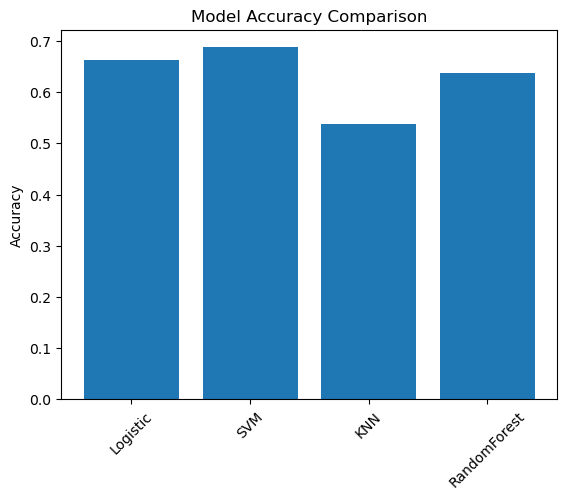

In [10]:
import matplotlib.pyplot as plt

names = list(results.keys())
acc = [results[m]["accuracy"] for m in names]

plt.bar(names, acc)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

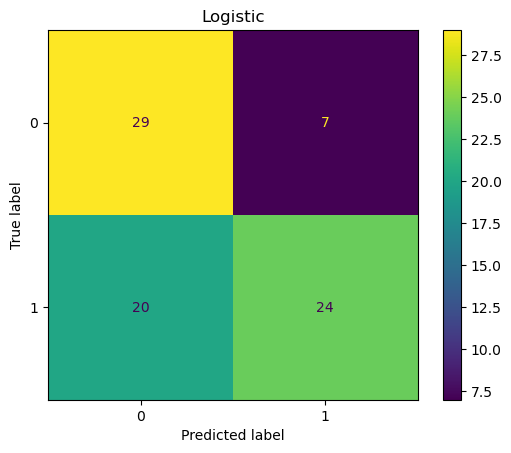

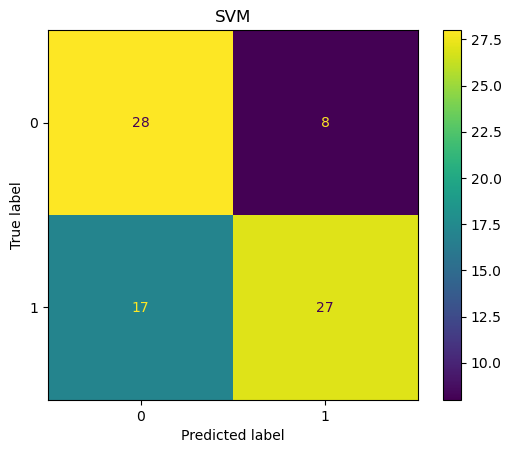

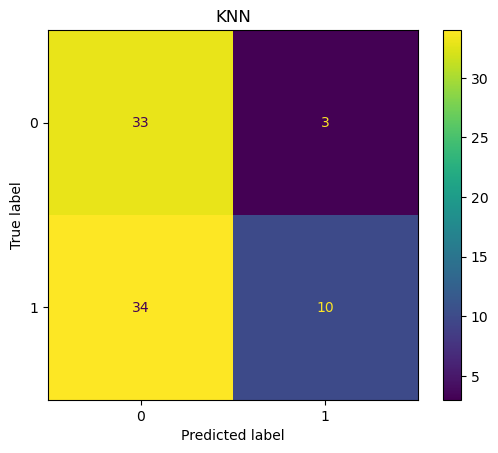

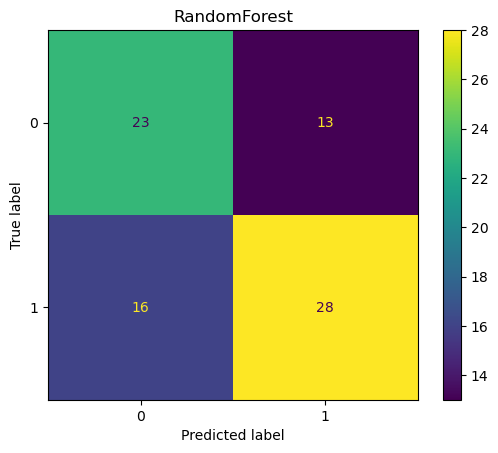

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    
    disp.plot()
    plt.title(name)
    plt.show()

Dataset Shape: (27558, 64, 64, 3)


c:\Users\Sgoff\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8808 - loss: 0.2818 - val_accuracy: 0.9505 - val_loss: 0.1811
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9540 - loss: 0.1490 - val_accuracy: 0.9534 - val_loss: 0.1406
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.9584 - loss: 0.1346 - val_accuracy: 0.9528 - val_loss: 0.1365
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 98s 143ms/step - accuracy: 0.9599 - loss: 0.1233 - val_accuracy: 0.9581 - val_loss: 0.1312
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 105s 152ms/step - accuracy: 0.9623 - loss: 0.1150 - val_accuracy: 0.9554 - val_loss: 0.1306
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 91s 132ms/step - accuracy: 0.9631 - loss: 0.1095 - val_accuracy: 0.9595 - val_loss: 0.1278
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 146s 212ms/step - accuracy: 0.9652 - loss: 0.1009 - val_accuracy: 0.9545 - val_loss: 0.1261
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 91s 132ms/step - accuracy: 0.9675 - loss: 0.

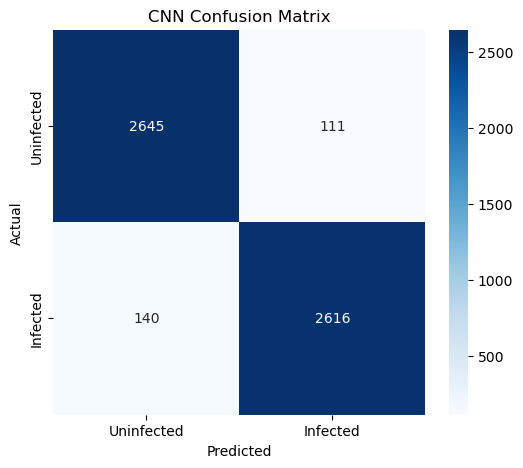

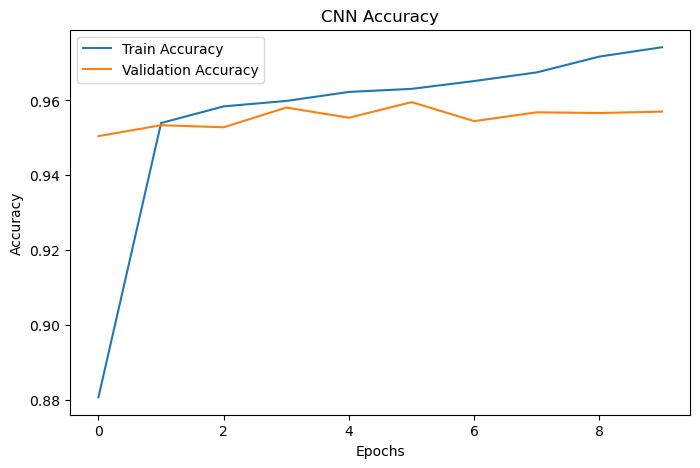

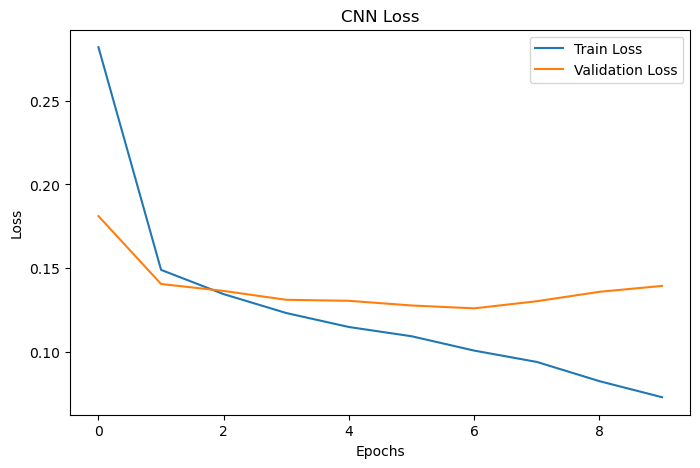

CNN model saved successfully!


In [13]:
# ===============================
# CNN MODEL (Run after ML models)
# ===============================

import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------
# LOAD IMAGE DATA AGAIN FOR CNN
# -----------------------------------

data = []
labels = []

# change path if needed
path = r"C:\Users\Sgoff\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images"

for label in ["Parasitized", "Uninfected"]:
    folder = os.path.join(path, label)
    class_label = 1 if label == "Parasitized" else 0

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (64, 64))
        data.append(image)
        labels.append(class_label)

X = np.array(data) / 255.0
y = np.array(labels)

print("Dataset Shape:", X.shape)

# -----------------------------------
# TRAIN TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------
# CNN MODEL
# -----------------------------------

cnn = Sequential()

cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Flatten())

cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(1, activation='sigmoid'))

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

# -----------------------------------
# TRAIN MODEL
# -----------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# -----------------------------------
# EVALUATION
# -----------------------------------

pred_prob = cnn.predict(X_test)
pred = (pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, pred)

print("\nCNN Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Uninfected", "Infected"],
            yticklabels=["Uninfected", "Infected"])
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------------
# ACCURACY GRAPH
# -----------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------------
# LOSS GRAPH
# -----------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------------
# SAVE MODEL
# -----------------------------------

cnn.save("cnn_malaria_model.h5")

print("CNN model saved successfully!")

In [18]:
from tensorflow.keras.models import load_model
model = load_model("cnn_malaria_model.keras")
print("CNN model saved!")



ValueError: File not found: filepath=cnn_malaria_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [17]:
model = load_model("cnn_malaria_model.h5", compile=False)